# Figure 1: Neural Data

In [1]:
import matplotlib.pyplot as plt

from neurodsp.sim import sim_powerlaw, sim_combined, sim_synaptic_current
from neurodsp.spectral import compute_spectrum
from neurodsp.burst import detect_bursts_dual_threshold
from neurodsp.plts import plot_time_series, plot_power_spectra, plot_bursts
from neurodsp.utils import create_times
from neurodsp.utils import set_random_seed

from fooof.plts import plot_spectrum
from fooof.plts.utils import add_shades
from fooof.utils import trim_spectrum

/var/folders/59/8y2d5r257c77vzymnqs47x080000gn/T/ipykernel_32510/2070590073.py:10: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof.plts import plot_spectrum


In [2]:
import seaborn as sns
sns.set_context('talk')

In [3]:
set_random_seed(505)

## Settings

In [4]:
# Simulation settings
fs = 500
n_seconds = 60

In [5]:
# Band settings
band_range = [4, 8]
band_col = '#46b870'

In [6]:
# Create times vector
times = create_times(n_seconds, fs)

## Simulations

In [7]:
# Simulate pink noise
pink = sim_powerlaw(n_seconds, fs, -1)

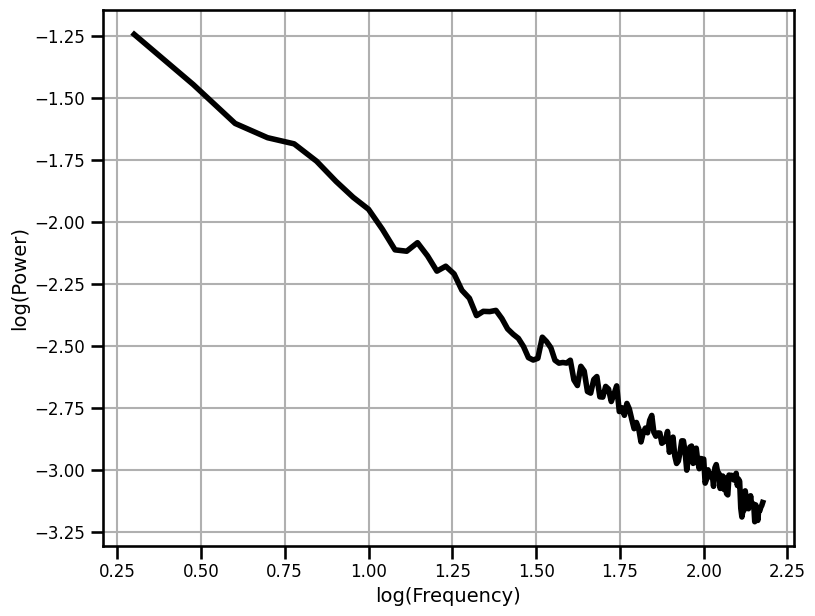

In [8]:
# Compute and plot power spectrum
freqs, powers = compute_spectrum(pink, fs)
plot_spectrum(*trim_spectrum(freqs, powers, [2, 150]), 
              log_freqs=True, log_powers=True, lw=4, color='black')

#### Combined Signal

In [9]:
# Define and simulate combined signal
comps = {'sim_powerlaw' : {'exponent' : -1, 'f_range' : [1., 75]},
         'sim_bursty_oscillation' : {'freq' : 6, 'enter_burst' : 0.25, 'leave_burst' : 0.3}}
sig = sim_combined(n_seconds, fs, comps, [0.5, 1])

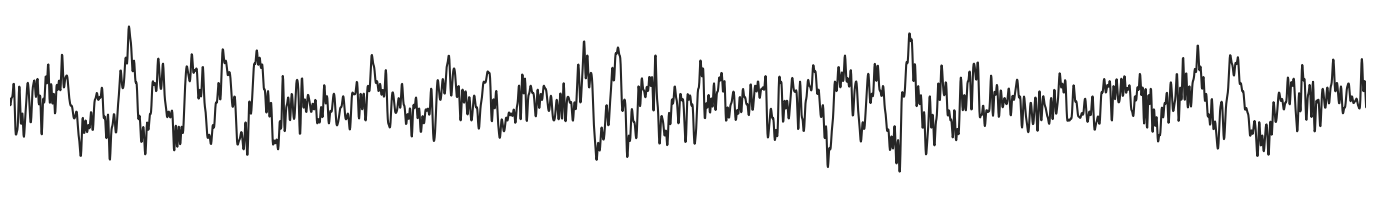

In [10]:
# Plot combined signal
plot_time_series(times, sig, lw=1.5, alpha=0.85, xlim=[8, 15], axis=False);

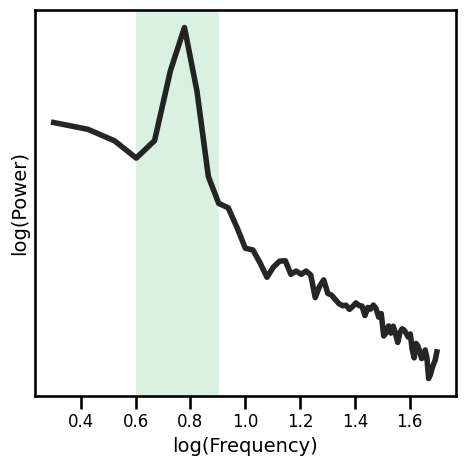

In [11]:
# Plot power spectrum of combined signal
_, ax = plt.subplots(figsize=(5, 5))
freqs, powers = compute_spectrum(sig, fs, nperseg=1.5*fs, noverlap=fs)
plot_spectrum(*trim_spectrum(freqs, powers, [2, 50]), alpha=0.85,
              log_freqs=True, log_powers=True, lw=4, color='black', ax=ax)
add_shades(plt.gca(), band_range, colors=band_col, logged=True)
plt.grid()
plt.yticks([]);

### XXX

In [12]:
# Detect bursts
bursts = detect_bursts_dual_threshold(sig, fs, (0.25, 2.), (4, 8))

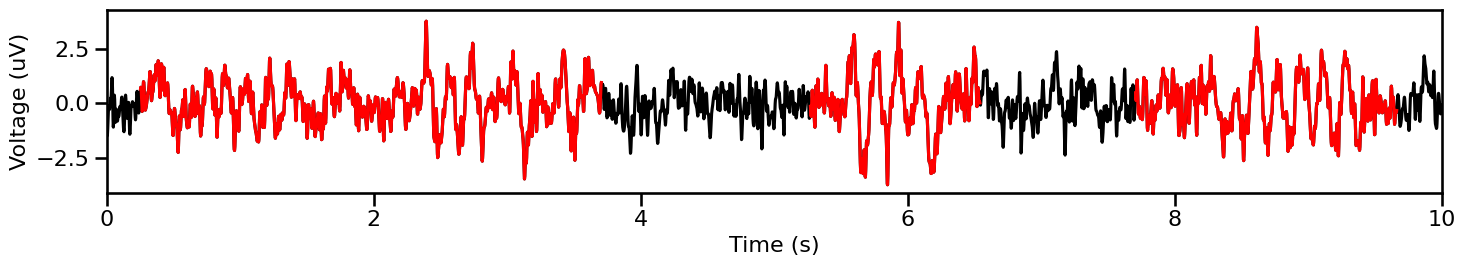

In [13]:
# Plot bursts
plot_bursts(times, sig, bursts, xlim=[0, 10])

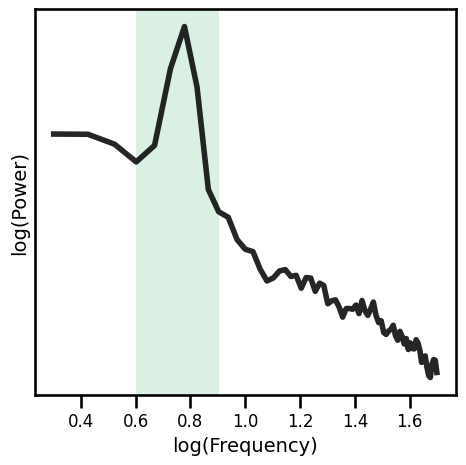

In [14]:
# Plot power spectrum of combined signal - burst sections
_, ax = plt.subplots(figsize=(5, 5))
freqs, powers = compute_spectrum(sig[bursts], fs, nperseg=1.5*fs, noverlap=fs)
plot_spectrum(*trim_spectrum(freqs, powers, [2, 50]), alpha=0.85,
              log_freqs=True, log_powers=True, lw=4, color='black', ax=ax)
add_shades(plt.gca(), band_range, colors=band_col, logged=True)
plt.grid()
plt.yticks([]);

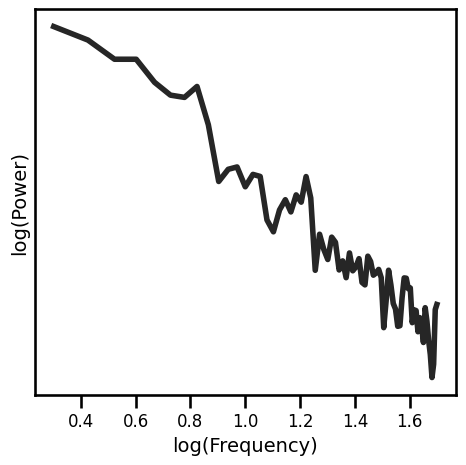

In [15]:
# Plot power spectrum of combined signal - non-burst sections
_, ax = plt.subplots(figsize=(5, 5))
freqs, powers = compute_spectrum(sig[~bursts], fs, nperseg=1.5*fs, noverlap=fs)
plot_spectrum(*trim_spectrum(freqs, powers, [2, 50]), alpha=0.85,
              log_freqs=True, log_powers=True, lw=4, color='black', ax=ax)
plt.grid()
plt.yticks([]);

#### Synaptic Signal

In [16]:
# Simulate synaptic curent
sig = sim_synaptic_current(n_seconds, fs)

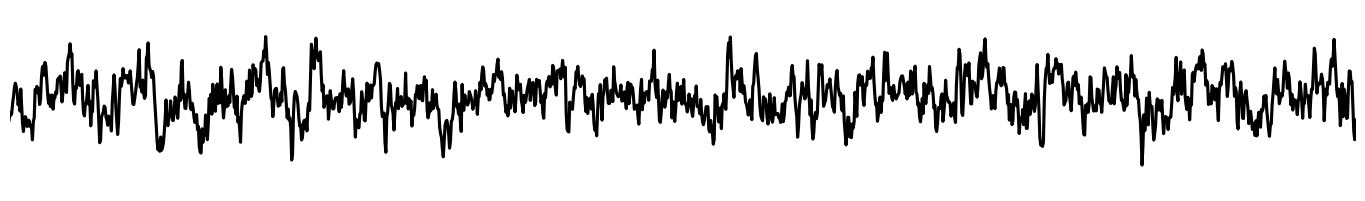

In [17]:
# Plot synaptic current
plot_time_series(times, sig, xlim=[10, 13], axis=False)

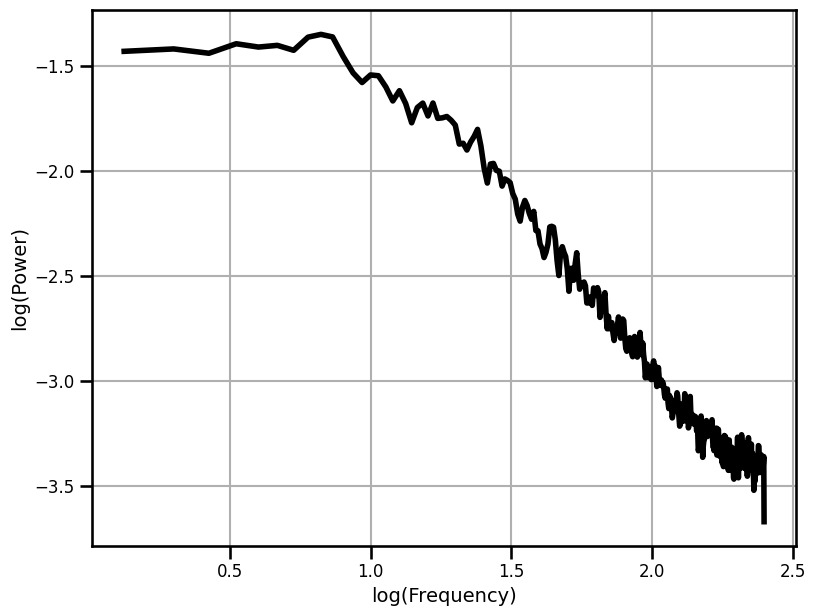

In [18]:
# Plot power spectrum of synaptic current signal
freqs, powers = compute_spectrum(sig, fs, nperseg=1.5*fs, noverlap=fs)
plot_spectrum(*trim_spectrum(freqs, powers, [1, 250]),
              log_freqs=True, log_powers=True, lw=4, color='black')

#### Combined Synaptic Signal

In [19]:
# Create combined signal with synaptic current signal
comps = {'sim_synaptic_current' : {}, 
         'sim_bursty_oscillation' : {'freq' : 6}}
sig = sim_combined(n_seconds, fs, comps, [0.75, 1])

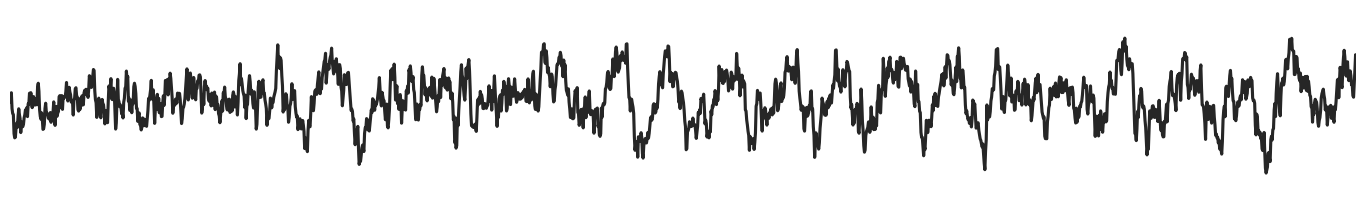

In [20]:
# Plot time series
plot_time_series(times, sig, xlim=[10, 14], alpha=0.85, axis=False)

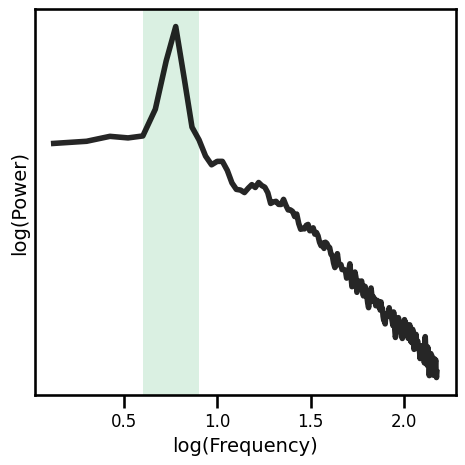

In [21]:
# Plot power spectrum of combined signal with synaptic current
_, ax = plt.subplots(figsize=(5, 5))
freqs, powers = compute_spectrum(sig, fs, nperseg=1.5*fs, noverlap=fs)
plot_spectrum(*trim_spectrum(freqs, powers, [1, 150]), alpha=0.85,
              log_freqs=True, log_powers=True, lw=4, color='black', ax=ax)
plt.grid()
plt.yticks([])
add_shades(plt.gca(), band_range, colors=band_col, logged=True)